In [ ]:
!pip install networkx pyvis
import networkx as nx
import heapq

def optimizing_packet_routing(graph,source, target):
    min_congestion = {node: float('inf') for node in graph}
    min_congestion[source] = 0
    previous_node = {node: None for node in graph}
    priority_queue = [(0,source)]
    while priority_queue:
        current_congestion,current_node = heapq.heappop(priority_queue)
        # skip outdated entries 
        if current_congestion > min_congestion[current_node]:
            continue 
        # exit if destination is reached
        if current_node == target:
            break 
        # exploring neighbors 
        for neighbor, link_congestion in graph[current_node]:
            total_congestion = link_congestion + current_congestion 
            if total_congestion < min_congestion[neighbor]:
                min_congestion[neighbor] = total_congestion 
                previous_node[neighbor] = current_node
                heapq.heappush(priority_queue, (total_congestion, neighbor))
    # if no path exists 
    if min_congestion[target] == float('inf'):
        return None, float('inf')
    # reconstruct path
    path = []
    current = target
    while current is not None:
        path.append(current)
        current = previous_node[current]
    path.reverse()
    return path, min_congestion[target]
# EXAMPLE OF WILKEN GROUP OF COMPANIES NETWORK
wilken_network = {
    "HQ_Router" : [
        ("Switch A", 2), 
        ("Switch B", 5), 
    ],
    "Switch_A": [
        ("Switch_B", 1),
        ("Hub_East", 7)
    ],
    "Switch_B": [
        ("Hub_East", 3),
        ("Server_Farm", 8)
    ],
    "Hub_East": [
        ("Server_Farm", 2)
    ],
    "Server_Farm": []
}
optimal_path, total_score = optimizing_packet_routing(wilken_group,"HQ_Router", "Server_Farm")
return "Optimal Path", ",".join(optimal_path)
return total_score

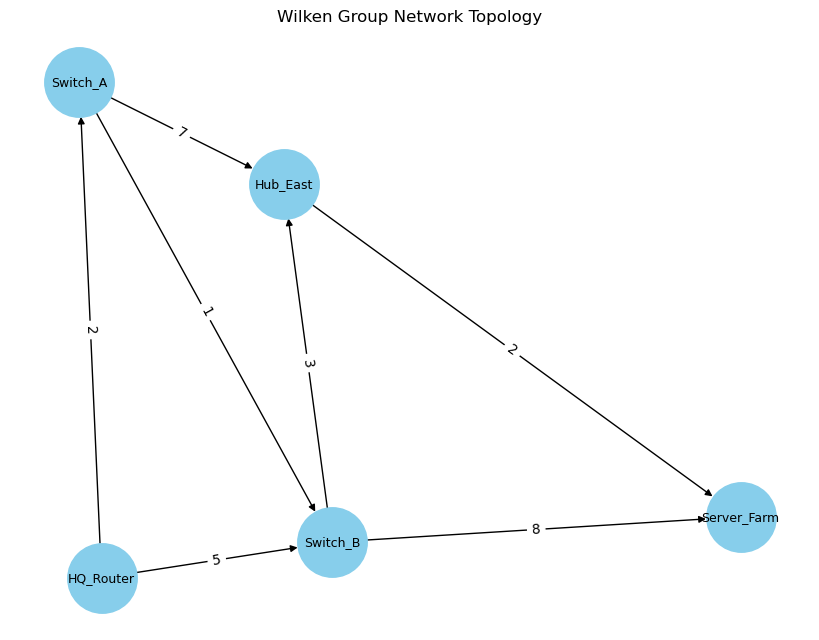

In [13]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

for node, edges in wilken_network.items():
    for neighbor, weight in edges:
        G.add_edge(node, neighbor, weight=weight)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="skyblue",
    font_size=9,
    arrows=True
)

edge_labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Wilken Group Network Topology")
plt.show()